# **TRAINING POLICY NOTEBOOK**

---

In this notebook you can run training on the LIBERO datasets for the ActionJEPA VLA.
Follow ALL the instructions in the notebook!


## **IMPORT**

In [ ]:
import os
import random
import json
from Dataset.PolicyDataset import PolicyDataset
from model.MLPActionJEPA import MLPActionJEPA
from model.TransformerActionJEPA import TransformerActionJEPA
from training.train import train_policy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2
from torch.amp import GradScaler
import pandas as pd
import matplotlib.pyplot as plt

# REPRODUCIBILITY
seed = 46

# Set seed for torch, numpy and random libraries
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(seed)
random.seed(seed)

# Set the devide mode on GPU (if available CUDA for Nvidia and  MPS for Apple Silicon) or CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

## HYPERPARAMETERS CONFIG

In [ ]:
# Loading the config.json file
with open('config_policy.json', 'r') as f:
    config = json.load(f)

# Hyperparameters definition
NUM_EPOCHS = config['num_epochs']
BATCH_SIZE = config['batch_size']
LEARNING_RATE = config['learning_rate']
DATASETS = config['datasets']   # it can be  a list of "libero_10", "libero_90", "libero_spatial", "libero_object", "libero_goal"...
TASK_IDS = config['task_ids'] # it can be a list of task_ids (from 0 to 9) depending on how much tasks of the datasets you want to train your model
MAX_LENGTH = config['max_length'] # it is the resulting tokens length after CLIP text encoder
POLICY = config['policy'] # it can be "mlp" or "transformer"
MIXED_PRECISION = config['mixed_precision'] # it can be true or false depending if you want to use float16 (instead of float32) using tensor cores of your gpu
NUM_WORKERS = config['num_workers']
PREFETCH_FACTOR = config['prefetch_factor']

print("="*40)
print(f"✅ Training config created!")
print(f"Epochs: {NUM_EPOCHS} | Batch Size: {BATCH_SIZE}")
print(f"LR: {LEARNING_RATE} ")
print(f"Dataset: {DATASETS}")
print(f"Tasks: {TASK_IDS}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Policy type: {POLICY}")
print(f"Mixed Precision: {MIXED_PRECISION}")
print("="*40)

## **DATASET CLASS AND SPLIT**

In [ ]:
dataset = PolicyDataset(datasets=DATASETS,
                        task_ids = TASK_IDS,
                        )

train_percentage = 0.7
val_percentage = 0.2

train_size = int(train_percentage*len(dataset))
val_size = int(val_percentage*len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset=dataset, lengths=[train_size, val_size, test_size])

print(f"Total dataset size (windows): {len(dataset)}, Train Size (windows): {len(train_dataset)}, Validation Size (windows): {len(val_dataset)}, Test Size (windows): {len(test_dataset)}")

In [ ]:
'''
if DATASET_TYPE == "all":
  selected_tasks = ["libero_10", "libero_90", "libero_spatial", "libero_goal", "libero_object"]
else:
  selected_tasks = [DATASET_TYPE]

processed_data_dir ='./processed_data'

dataset = LiberoDataset(data_dir=processed_data_dir,
                        selected_tasks=selected_tasks,
                        num_frames=NUM_FRAMES,
                        use_features = PREPROCESSING_WITH_BACKBONE
                        )

train_percentage = 0.7
val_percentage = 0.2

train_size = int(train_percentage*len(dataset))
val_size = int(val_percentage*len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset=dataset, lengths=[train_size, val_size, test_size])

print(f"Total dataset size (windows): {len(dataset)}, Train Size (windows): {len(train_dataset)}, Validation Size (windows): {len(val_dataset)}, Test Size (windows): {len(test_dataset)}")
'''

## **MODEL DEFINITION**

In [ ]:
checkpoints_path = "./checkpoints"
# Path for all the models
vjepa_path = os.path.join(checkpoints_path,"facebook/vjepa2-vitg-fpc64-256")
vjepa_pred_path = os.path.join(checkpoints_path,"facebook/jepa-wms/vjepa2_ac_droid.pth.tar/vjepa2_ac_droid.pth.tar")
clip_path = os.path.join(checkpoints_path,"openai/clip-vit-large-patch14")
finetuned_predictor = "./results/predictor/2026_05_10__18_44/best_model.pth"

if POLICY == "mlp":
    model = MLPActionJEPA(
        vjepa_encoder_path=vjepa_path,
        vjepa_predictor_path=vjepa_pred_path,
        clip_model_path=clip_path,
        device=device
    ).to(device)
else:
    model = TransformerActionJEPA(
        vjepa_encoder_path=vjepa_path,
        vjepa_predictor_path=finetuned_predictor,
        finetuned_pred = True,
        clip_model_path=clip_path,
        device=device,
    ).to(device)

model.print_model_info()

## **TRAIN**

In [ ]:
with open('config_policy.json', 'r') as f:
    config = json.load(f)

# Name of the directory for the results
results_dir_path = "./results/policy"
os.makedirs(results_dir_path, exist_ok=True)

loss_fn = nn.MSELoss()
# Definition of the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr = LEARNING_RATE)

if MIXED_PRECISION:
    scaler = GradScaler()
else:
    scaler = None

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=PREFETCH_FACTOR,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=PREFETCH_FACTOR,
    persistent_workers=True
)

training_dir_path = train_policy(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=NUM_EPOCHS,
    config=config,
    device=device,
    scaler=scaler,
    results_dir_path=results_dir_path,
)

## PLOTS

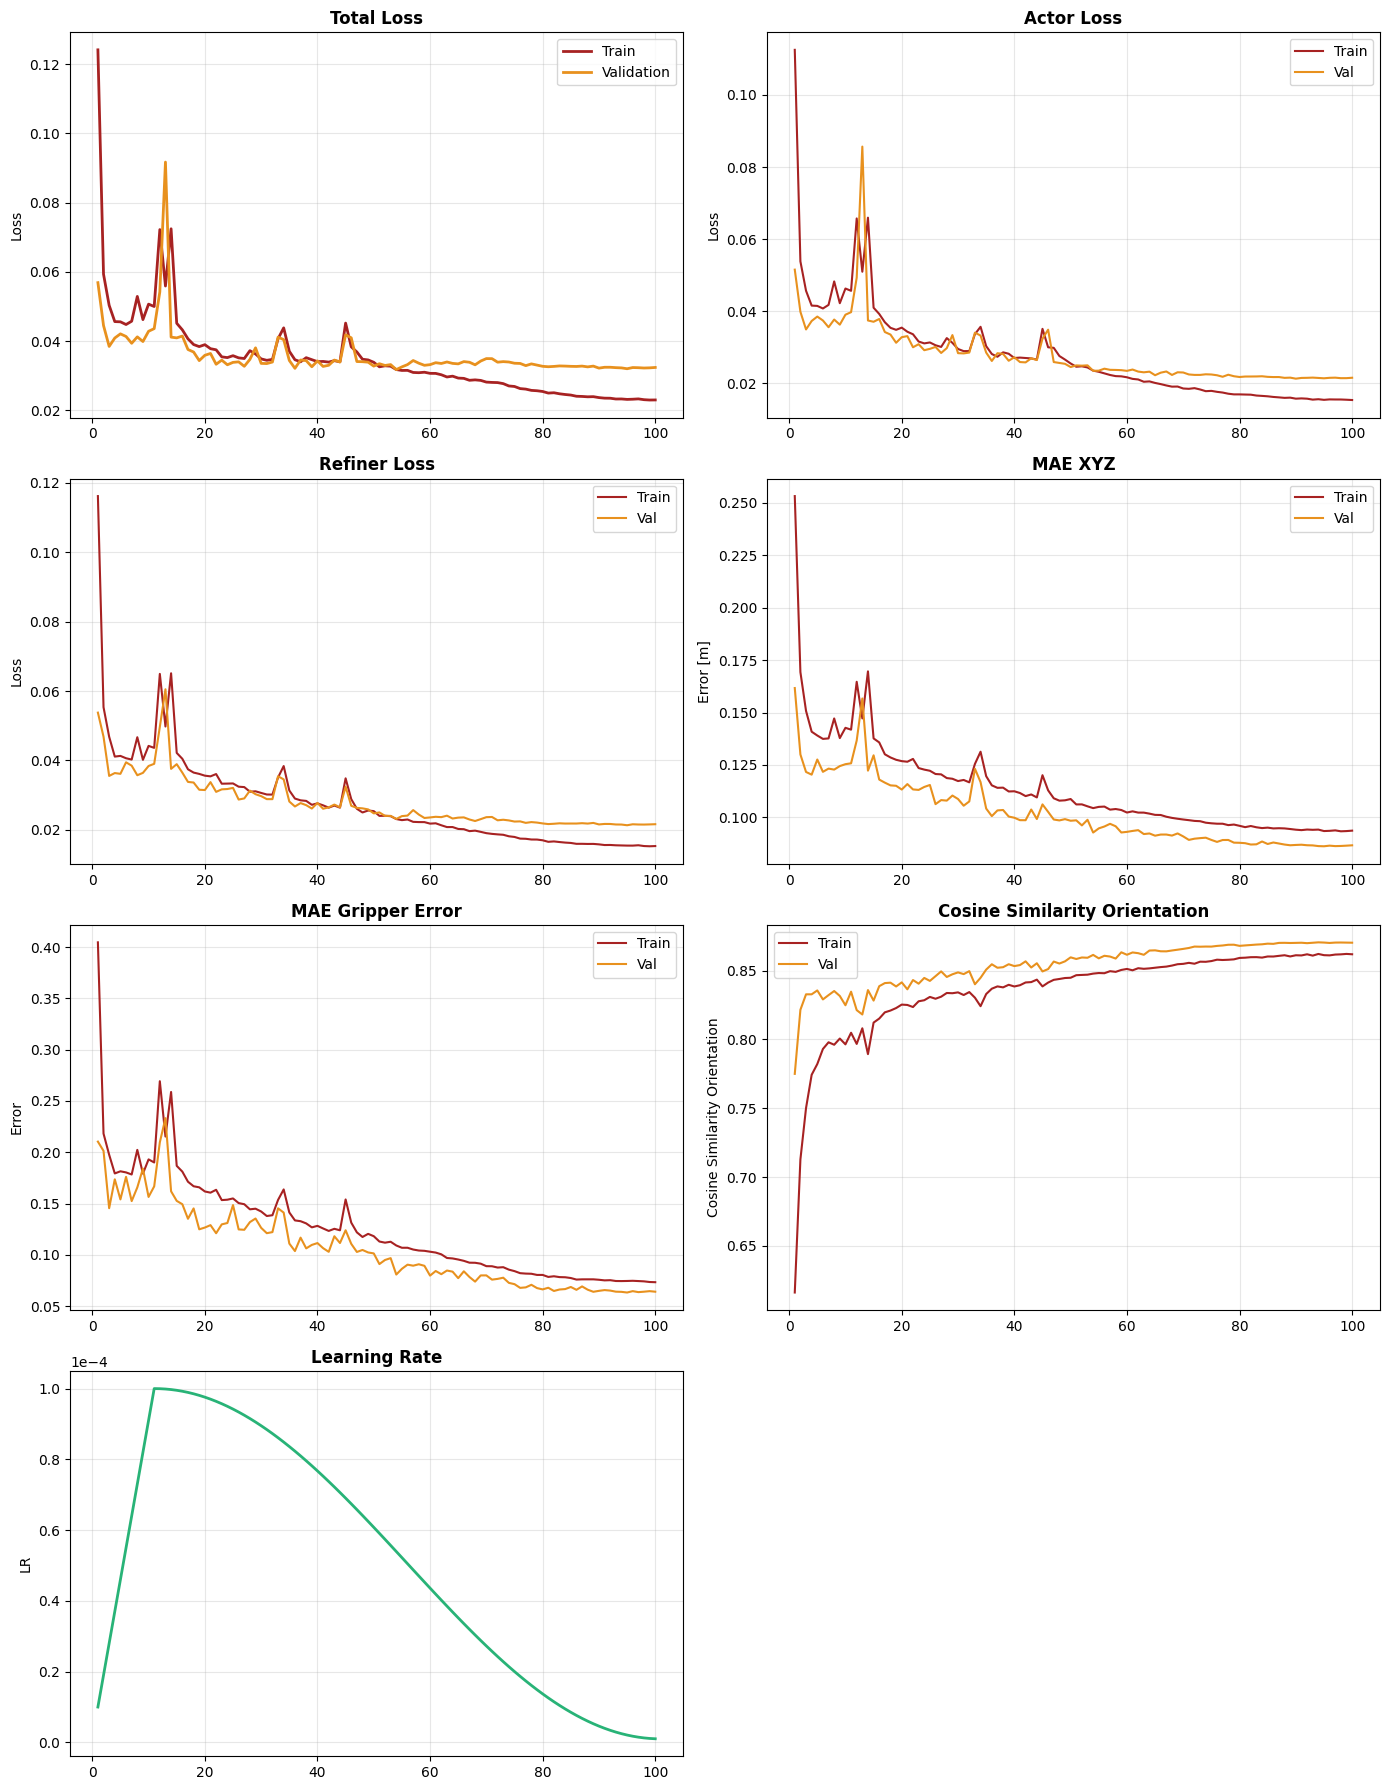

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

training_dir_path = "./results/policy/2026_05_13__09_57"
metrics_path = os.path.join(training_dir_path, 'metrics.csv')

df = pd.read_csv(metrics_path)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()
plt.style.use('seaborn-v0_8-muted')

c_train = "#a72222"
c_val = "#e8911e"

axes[0].plot(df['Epoch'], df['loss_train'], label='Train', linewidth=2, color=c_train)
axes[0].plot(df['Epoch'], df['loss_val'], label='Validation', linewidth=2, color=c_val)
axes[0].set_title('Total Loss', fontweight='bold')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df['Epoch'], df['loss_actor_train'], label='Train', color=c_train)
axes[1].plot(df['Epoch'], df['loss_actor_val'], label='Val', color=c_val)
axes[1].set_title('Actor Loss', fontweight='bold')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(df['Epoch'], df['loss_refiner_train'], label='Train', color=c_train)
axes[2].plot(df['Epoch'], df['loss_refiner_val'], label='Val', color=c_val)
axes[2].set_title('Refiner Loss', fontweight='bold')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[3].plot(df['Epoch'], df['mae_xyz_train'], label='Train', color=c_train)
axes[3].plot(df['Epoch'], df['mae_xyz_val'], label='Val', color=c_val)
axes[3].set_title('MAE XYZ', fontweight='bold')
axes[3].set_ylabel('Error [m]')
axes[3].grid(True, alpha=0.3)
axes[3].legend()

axes[4].plot(df['Epoch'], df['mae_gripper_train'], label='Train', color=c_train)
axes[4].plot(df['Epoch'], df['mae_gripper_val'], label='Val', color=c_val)
axes[4].set_title('MAE Gripper Error', fontweight='bold')
axes[4].set_ylabel('Error')
axes[4].grid(True, alpha=0.3)
axes[4].legend()

axes[5].plot(df['Epoch'], df['cosim_ori_train'], label='Train', color=c_train)
axes[5].plot(df['Epoch'], df['cosim_ori_val'], label='Val', color=c_val)
axes[5].set_title('Cosine Similarity Orientation', fontweight='bold')
axes[5].set_ylabel('Cosine Similarity Orientation')
axes[5].grid(True, alpha=0.3)
axes[5].legend()

axes[6].plot(df['Epoch'], df['lr_train'], color="#28b377", linewidth=2)
axes[6].set_title('Learning Rate', fontweight='bold')
axes[6].set_ylabel('LR')
axes[6].grid(True, alpha=0.3)
axes[6].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

fig.delaxes(axes[7])

plt.tight_layout()
plt.savefig(os.path.join(training_dir_path,'plots.png'), dpi=300)
plt.show()